# Notebook 01: baseline models (DLinear, NLinear, XGBoost, LSTM)

Trains the four baselines of the model comparison on the CPCB city-day data (`city_day.csv`, 26 cities, 12
pollutant concentrations, target next-day AQI) at lookbacks 7, 14, 21 and 30 days, under the same evaluation protocol
as notebook 02.

**Evaluation protocol (Revision 1).** Every city's series is placed on a continuous daily calendar. Input
gaps of at most 3 days are filled from the last observed day, pollutant gaps from the city's own past readings only,
and targets are never filled. A window is kept only if its last input day has at least 180 available days of history.
All cities share one calendar split by target date: training before 1 Apr 2019, validation from 1 Apr to 30 Jun 2019,
test from 1 Jul 2019 to 1 Jul 2020. Every accuracy is also reported for the pre-lockdown period and for
lockdown/Unlock (targets from 25 Mar 2020). 18 cities have training windows under these rules.

**Outputs.** The comparison table and plots below, and two files written to the Colab session
(`phase1_colab_comparison_metrics.csv`, `phase1_colab_comparison_summary.json`, copied to `results/` in this
repository). The LSTM row of the model comparison is the PyTorch LSTM of notebook 02 (Section 7c), trained under the
same pipeline as the other notebook 02 models. This notebook's Keras LSTM is its own baseline.

**Runtime.** One Colab GPU session.

Run order of the repository: `01_phase1_baselines_r1`, `02_ceemdan_itransformer_shap_r1`, `02_ceemdan_itransformer_shap_r1_ext`, `03_shap_background_check_r1_ext`. The README explains the decision tags used in comments and printed output (for example R1.13 or I-15).

## Sections and reviewer comments

| Section | Produces | Reviewer comments |
|---|---|---|
| 1 Setup | packages, device, seeds | |
| 2 Dataset | `city_day.csv` | R1.5 |
| 3 to 4 Configuration and preprocessing | daily calendar, own-past fill, minimum history, common-date split, period labels | R1.9, R1.10, R1.11, R3.3 |
| 5 to 8 Models | DLinear, NLinear, XGBoost, LSTM (Keras) | R2 (baseline comparison) |
| 9 to 10 Training, evaluation, comparison | metrics at lookbacks 7, 14, 21, 30, full test year and both periods | R1.10, R1.13 |

## 1. Setup

### 1.1 Package installs

Colab's runtime already ships GPU-linked builds of `torch`, `tensorflow`, `numpy`,
`pandas`, `scikit-learn`, and `matplotlib` — we deliberately do **not** pip-install or
upgrade any of these, since reinstalling risks breaking the pre-linked CUDA wiring.

The only package this phase imports that might be missing (or present in an older
version) on a given Colab image is `xgboost`. The cell below installs it **only if it
isn't already importable** — no forced reinstall.

In [1]:
import importlib.util

if importlib.util.find_spec("xgboost") is None:
    print("xgboost not found — installing...")
    %pip install -q xgboost
else:
    print("xgboost already available — skipping install (per project constraint: "
          "never reinstall preinstalled GPU-linked packages).")


xgboost already available — skipping install (per project constraint: never reinstall preinstalled GPU-linked packages).


### 1.2 Imports

In [2]:
import json
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
# Revision 1, I-11: matplotlib.use("Agg") removed. Under Agg, plt.show() displayed nothing in Colab, and the plots
# were not saved anywhere, so the two Section 10 plot cells had no output.
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("torch:", torch.__version__)
print("tensorflow:", tf.__version__)
print("xgboost:", xgb.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


torch: 2.11.0+cu130
tensorflow: 2.20.0
xgboost: 3.4.1
pandas: 2.2.3
numpy: 2.1.3


### 1.3 GPU detection

`DLinearTrainer` / `NLinearTrainer` (PyTorch) accept a `device` constructor argument
that defaults to `'cpu'` and — in the original `train_*.py` / `compare_lookback_comprehensive.py`
scripts — is **never overridden**, so those scripts train on CPU even when a GPU is
present. Here we detect the device once and pass it explicitly into every PyTorch model
we construct below.

For the Keras/TensorFlow LSTM baseline, TensorFlow uses the GPU automatically if one is
visible to it (no explicit device argument needed) — the print below just confirms
whether TF can see the Colab GPU.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[PyTorch] Using device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

print("\n[TensorFlow] Visible GPU devices:", tf.config.list_physical_devices("GPU"))


[PyTorch] Using device: cuda
  GPU: Tesla T4

[TensorFlow] Visible GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.4 Random seeding for reproducibility

Every stochastic component is seeded from a single `RANDOM_SEED` so the run is deterministic
and reproducible: numpy, Python's `random`, PyTorch (CPU + CUDA), TensorFlow/Keras, and
XGBoost's `random_state`. The train/val/test split is chronological (index-sliced, not
shuffled), so it carries no split-level randomness; the `DataLoader`s run with `shuffle=False`.

For full GPU determinism the seeding cell below also sets
`torch.backends.cudnn.deterministic = True` / `benchmark = False` and calls
`tf.config.experimental.enable_op_determinism()`, since cuDNN's default convolution/pooling
and TensorFlow's cuDNN LSTM kernels otherwise select non-deterministic algorithms regardless
of the seed.

In [4]:
RANDOM_SEED = 42  # from config_phase1.py

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # no-op if no GPU

# Deterministic cuDNN kernels -- without this, AvgPool1d/backward on GPU can pick a
# different (faster but non-deterministic) algorithm on each run, even with the seed
# above fixed. Same fix already applied in phase4_advanced_v2.ipynb.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tf.random.set_seed(RANDOM_SEED)
# TF/Keras's cuDNN-backed LSTM kernel is non-deterministic on GPU by default (atomic-add
# reductions in its backward pass), even with tf.random.set_seed set. This forces the
# deterministic kernel variants instead.
tf.config.experimental.enable_op_determinism()

print(f"Seeded numpy, random, torch (CPU+CUDA), and tensorflow with RANDOM_SEED={RANDOM_SEED}")
print("Enabled cuDNN determinism (torch) and op determinism (tensorflow).")


Seeded numpy, random, torch (CPU+CUDA), and tensorflow with RANDOM_SEED=42
Enabled cuDNN determinism (torch) and op determinism (tensorflow).


## 2. Dataset

Upload `city_day.csv` (found locally at
`Implementation\\Datasets\\kaggle\\2\\city_day.csv`) when prompted by the cell below.

The helper function also checks a few common alternate locations first, so re-running
this cell after the first successful upload (or if you've mounted Google Drive / already
placed the file at `/content/city_day.csv`) won't prompt again.

In [5]:
def locate_or_upload_csv(filename="city_day.csv"):
    """Return a Path to `filename`, uploading it via the Colab file picker if needed.

    Search order:
      1. Current working directory (e.g. re-running this cell after a prior upload)
      2. /content/<filename>                       (default Colab upload target)
      3. /content/drive/MyDrive/<filename>          (if Google Drive is mounted)
      4. Fall back to files.upload() (Colab file picker)
    """
    candidates = [
        Path(filename),
        Path("/content") / filename,
        Path("/content/drive/MyDrive") / filename,
        # Local (non-Colab) fallbacks -- covers running this notebook from a local
        # Jupyter/VS Code kernel with cwd at the repo root or at this notebook's own
        # folder (Implementation/colab_notebooks/). Matches the same fallback already
        # present in phase3_transformers.ipynb.
        Path("Implementation/Datasets/kaggle/2") / filename,
        Path("../Datasets/kaggle/2") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            print(f"Found dataset at: {candidate.resolve()}")
            return candidate

    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            f"'{filename}' not found locally and google.colab.files is unavailable "
            f"(not running in Colab). Place the file at one of: "
            f"{[str(c) for c in candidates]}"
        )

    print(f"'{filename}' not found — please choose it from the upload dialog "
          f"(Implementation/Datasets/kaggle/2/city_day.csv on your machine).")
    uploaded = files.upload()
    if filename not in uploaded and len(uploaded) == 1:
        # User uploaded under a different name — rename to expected filename.
        (only_name,) = uploaded.keys()
        Path(only_name).rename(filename)
    elif filename not in uploaded:
        raise FileNotFoundError(
            f"Upload did not contain '{filename}'. Uploaded: {list(uploaded.keys())}"
        )

    result = Path(filename)
    print(f"Uploaded dataset to: {result.resolve()}")
    return result


DATA_FILE = locate_or_upload_csv("city_day.csv")


'city_day.csv' not found — please choose it from the upload dialog (Implementation/Datasets/kaggle/2/city_day.csv on your machine).


Saving city_day.csv to city_day.csv
Uploaded dataset to: /content/city_day.csv


## 3. Configuration (transcribed from `config_phase1.py`)

In [6]:
# Feature and target columns (config_phase1.py)
FEATURE_COLUMNS = [
    "PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]
TARGET_COLUMN = "AQI"

# Data split (chronological, not shuffled): Revision 1, R1.9/R1.10, common target dates for every city
# (training before 1 Apr 2019, validation to 30 Jun 2019, test 1 Jul 2019 to 1 Jul 2020). The dates are
# defined in the R1.9 helper cell (R19_VAL_START, R19_TEST_START, R19_DATA_END).

# Lookback periods for sequence-based models
LOOKBACK_PERIODS = [7, 14, 21, 30]   # Revision 1, R1.13: the lookbacks of notebook 02, so Table 2 exists at the selected one

# Model hyperparameters (config_phase1.py HYPERPARAMETERS dict).
# device is overridden below to the detected device (Known Fact #1) instead of the
# original hard-coded 'cpu'.
HYPERPARAMETERS = {
    "dlinear": {
        "seq_len": 14,              # overridden per lookback in the training loop
        "pred_len": 1,
        "seasonal_period": 7,       # weekly seasonality
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "device": device,           # was 'cpu' in config_phase1.py; wired to detected device
    },
    "nlinear": {
        "seq_len": 14,
        "pred_len": 1,
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "device": device,           # was 'cpu' in config_phase1.py; wired to detected device
    },
    "xgboost": {
        "n_estimators": 200,
        "max_depth": 7,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "random_state": RANDOM_SEED,
        "seq_len": 14,
        "pred_len": 1,
    },
    "lstm": {
        "seq_len": 14,
        "pred_len": 1,
    }
}

METRICS = ["rmse", "mae", "mape", "r2"]
VERBOSE = True

print(f"LOOKBACK_PERIODS = {LOOKBACK_PERIODS}")
print(f"FEATURE_COLUMNS ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print("Split -> common target dates (R1.9/R1.10), see the R1.9 helper cell")


LOOKBACK_PERIODS = [7, 14, 21, 30]
FEATURE_COLUMNS (12): ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
TARGET_COLUMN = AQI
Split -> common target dates (R1.9/R1.10), see the R1.9 helper cell


## 4. Preprocessing

Two data paths, both on the daily calendar and the common-date split of the helper cells below:

- **`AQIDataLoader`**: sliding windows of length L for DLinear, NLinear and LSTM.
- **`XGBoostDataProcessor`**: L lags per pollutant plus 7-day rolling mean and s.d., computed per city, for XGBoost.
  Same-day pollutant values are never features.

**Evaluation protocol (Revision 1).** Every city's series is placed on a continuous daily calendar. Input
gaps of at most 3 days are filled from the last observed day, pollutant gaps from the city's own past readings only,
and targets are never filled. A window is kept only if its last input day has at least 180 available days of history.
All cities share one calendar split by target date: training before 1 Apr 2019, validation from 1 Apr to 30 Jun 2019,
test from 1 Jul 2019 to 1 Jul 2020. Every accuracy is also reported for the pre-lockdown period and for
lockdown/Unlock (targets from 25 Mar 2020). 18 cities have training windows under these rules.

Scalers are fit on training rows only.

In [7]:
class AQIDataLoader:
    """Load and preprocess AQI data for baseline models (DLinear, NLinear, LSTM)."""

    def __init__(self, data_path=DATA_FILE, random_seed=RANDOM_SEED):
        self.data_path = Path(data_path)
        self.random_seed = random_seed
        np.random.seed(random_seed)
        if VERBOSE:
            print(f"[AQIDataLoader] Initialized with seed {random_seed}")

    def load_and_clean(self):
        """Load and clean data"""
        if VERBOSE:
            print(f"\n[AQIDataLoader] Loading data from {self.data_path}...")

        df = pd.read_csv(self.data_path)
        if VERBOSE:
            print(f"  Raw shape: {df.shape}")

        # Remove missing targets
        df = df.dropna(subset=[TARGET_COLUMN])

        # Revision 1, N1/R1.11 (P3): pollutant gaps are no longer filled here. The submitted
        # ffill().bfill() back-filled from later dates and, being ungrouped, from other cities, and the
        # mean fill used the whole dataset. Each window builder now fills them on the daily calendar
        # (n1_pollutant_calendar, n1_fill_constant).

        if VERBOSE:
            print(f"  Cleaned shape: {df.shape}")

        return df

    def create_sequences(self, X, y, seq_len=14):
        """Create sliding window sequences"""
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_len):
            X_seq.append(X[i:i + seq_len])
            y_seq.append(y[i + seq_len])
        return np.array(X_seq), np.array(y_seq)

    def prepare_data(self, df, seq_len=14):
        """Prepare data for DL models (DLinear, NLinear, LSTM).

        Sequences are windowed and split per city in chronological order, then
        concatenated, so the split is a chronological forecast split. Scalers
        are fit on the training rows only.
        """
        if VERBOSE:
            print(f"\n[AQIDataLoader] Preparing sequences (seq_len={seq_len})...")

        cities = sorted(df["City"].unique())
        city_raw = {}
        for city in cities:
            df_c = df[df["City"] == city].sort_values("Date").reset_index(drop=True)
            # Revision 1, R3.3 D1(b): daily calendar with short gaps filled from past values.
            cal_c, observed, available = d1_calendar_city(df_c, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
            # Revision 1, R1.9/R1.10 + R1.1: windows after the minimum history, split by common target dates.
            starts, split = r19_city_windows(cal_c["Date"], observed, available, seq_len)
            if split[0] == 0:
                continue   # no training window: not modelled
            city_raw[city] = {
                "X": n1_pollutant_calendar(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed, available),   # N1
                "n1_readings": n1_readings(cal_c[FEATURE_COLUMNS].values.astype(np.float64), observed),
                "y": cal_c[TARGET_COLUMN].values.astype(np.float64),
                "test_dates": r110_test_dates(cal_c["Date"], starts, split, seq_len),   # Revision 1, R1.9-4
                "n": len(cal_c),
                "available": available,
                "starts": starts,
                "split": split,
            }
        valid_cities = list(city_raw.keys())
        r19_check_cities(valid_cities, "AQIDataLoader (notebook 01)")

        # Per-city split indices (train_end, val_end, n_seq) over the city's windows, from the common
        # target dates (Revision 1, R1.9/R1.10).
        city_splits = {city: city_raw[city]["split"] for city in valid_cities}

        n1_fill_constant(city_raw, "X", city_splits, seq_len)   # Revision 1, N1: pooled training constant before the first reading

        # Scalers fit on the training rows only (D1: available days up to the
        # last training target of each city).
        train_X_list, train_y_list = [], []
        for city in valid_cities:
            train_starts = city_raw[city]["starts"][:city_splits[city][0]]
            rows = d1_train_row_mask(city_raw[city]["n"], train_starts, seq_len, city_raw[city]["available"])
            train_X_list.append(city_raw[city]["X"][rows])
            train_y_list.append(city_raw[city]["y"][rows])

        scaler_X = MinMaxScaler(feature_range=(0, 1)).fit(np.vstack(train_X_list))
        scaler_y = MinMaxScaler(feature_range=(0, 1)).fit(
            np.concatenate(train_y_list).reshape(-1, 1)
        )

        X_train, y_train = [], []
        X_val, y_val = [], []
        X_test, y_test = [], []

        for city in valid_cities:
            d = city_raw[city]
            train_end, val_end, n_seq = city_splits[city]

            X_sc = scaler_X.transform(d["X"])
            y_sc = scaler_y.transform(d["y"].reshape(-1, 1)).ravel()

            for seq_i, i in enumerate(d["starts"]):   # D1: usable windows only
                X_win = X_sc[i:i + seq_len]
                y_tgt = y_sc[i + seq_len]
                if seq_i < train_end:
                    X_train.append(X_win)
                    y_train.append(y_tgt)
                elif seq_i < val_end:
                    X_val.append(X_win)
                    y_val.append(y_tgt)
                else:
                    X_test.append(X_win)
                    y_test.append(y_tgt)

        X_train = np.array(X_train)
        y_train = np.array(y_train).reshape(-1, 1)
        X_val = np.array(X_val)
        y_val = np.array(y_val).reshape(-1, 1)
        X_test = np.array(X_test)
        y_test = np.array(y_test).reshape(-1, 1)
        for _arr in (X_train, y_train, X_val, y_val, X_test, y_test):
            assert np.isfinite(_arr).all(), "D1: a window contains an unavailable day"

        if VERBOSE:
            print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

        return {
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test,
            "scaler_X": scaler_X,
            "scaler_y": scaler_y,
            "feature_names": FEATURE_COLUMNS,
            "valid_cities": valid_cities,
            "test_dates": np.concatenate([city_raw[c]["test_dates"] for c in valid_cities]),   # Revision 1, R1.9-4
        }


class XGBoostDataProcessor:
    """Prepare data for XGBoost (uses lag features instead of sequences).

    Lag and rolling features are computed per city, and same-day pollutant
    columns never enter feature_cols, so every feature is strictly lagged.
    The split is computed per city in chronological order, then
    concatenated, and scaler_y is fit on the training split only.
    """

    def __init__(self, seq_len=14, random_seed=RANDOM_SEED):
        self.seq_len = seq_len
        self.random_seed = random_seed
        np.random.seed(random_seed)

    def create_lag_features(self, df):
        """Create per-city lag and rolling features for tree-based models"""
        if VERBOSE:
            print(f"\n[XGBoostDataProcessor] Creating lag features (seq_len={self.seq_len})...")

        # Revision 1, R3.3 D1(b): each city on a daily calendar with short gaps filled from
        # past values, so lag k is always the value k calendar days earlier.
        # Revision 1, N1/R1.11 (P3, option (c)): pollutants are the last reading within 3 calendar days,
        # then the median of the city's own readings in the previous 365 available days, and a pooled
        # training constant before the first reading.
        # Revision 1, R1.9/R1.10 + R1.1: the rows kept below are exactly the target days of the city's
        # windows from r19_city_windows (asserted after dropna), each labelled with its split part, so
        # XGBoost uses the same cities, target days and split as the sequence models.
        cal, city_raw = {}, {}
        for city, df_c in df.groupby("City"):
            cal_c, observed, available = d1_calendar_city(df_c, list(FEATURE_COLUMNS) + [TARGET_COLUMN])
            starts, split = r19_city_windows(cal_c["Date"], observed, available, self.seq_len)
            if split[0] == 0:
                continue   # no training window: not modelled
            part = np.full(len(cal_c), "", dtype=object)
            targets = starts + self.seq_len
            part[targets[:split[0]]] = "train"
            part[targets[split[0]:split[1]]] = "val"
            part[targets[split[1]:]] = "test"
            cal_c["City"] = city
            cal_c["_r1_part"] = part
            cal[city] = cal_c
            city_raw[city] = {
                "X": n1_pollutant_calendar(cal_c[FEATURE_COLUMNS].to_numpy(np.float64), observed, available),
                "n1_readings": n1_readings(cal_c[FEATURE_COLUMNS].to_numpy(np.float64), observed),
                "n": len(cal_c),
                "available": available,
                "starts": starts,
                "split": split,
            }
        r19_check_cities(list(city_raw), "XGBoostDataProcessor")
        n1_fill_constant(city_raw, "X", {c: d["split"] for c, d in city_raw.items()}, self.seq_len)
        frames = []
        for city, cal_c in cal.items():
            cal_c[FEATURE_COLUMNS] = city_raw[city]["X"]
            frames.append(cal_c)
        df_copy = pd.concat(frames, ignore_index=True)
        grouped = df_copy.groupby("City")

        # Lag features: strictly past values, grouped per city so no city's
        # trailing rows bleed into the next city's leading rows.
        for col in FEATURE_COLUMNS:
            for lag in range(1, self.seq_len + 1):
                df_copy[f"{col}_lag_{lag}"] = grouped[col].shift(lag)

        # Rolling statistics computed over the lag-1 series (days [t-7, t-1]),
        # never the same-day column, so they cannot see day t itself.
        for col in FEATURE_COLUMNS:
            shifted = grouped[col].shift(1)
            df_copy[f"{col}_rolling_mean_7"] = shifted.groupby(df_copy["City"]).transform(
                lambda s: s.rolling(7).mean()
            )
            df_copy[f"{col}_rolling_std_7"] = shifted.groupby(df_copy["City"]).transform(
                lambda s: s.rolling(7).std()
            )

        # Keep only the window target days. Their lags and rolling statistics lie inside the window's
        # input days, which are all available, so dropna must remove nothing (asserted).
        df_copy = df_copy[df_copy["_r1_part"] != ""]
        n_targets = len(df_copy)
        df_copy = df_copy.dropna().reset_index(drop=True)
        assert len(df_copy) == n_targets == sum(len(d["starts"]) for d in city_raw.values()), \
            "R1.9: XGBoost rows differ from the window targets, so the split and the training rows would be wrong"

        if VERBOSE:
            print(f"  Features created: {df_copy.shape[1]}")

        return df_copy

    def prepare_data(self, df):
        """Prepare data for XGBoost"""
        df_processed = self.create_lag_features(df)
        parts = df_processed.pop("_r1_part")

        # Only engineered lag/rolling columns are features. Same-day pollutant
        # values (which mathematically determine same-day AQI via the CPCB
        # sub-index formula) are excluded entirely, along with City/Date/AQI/AQI_Bucket.
        feature_cols = [col for col in df_processed.columns
                         if col not in FEATURE_COLUMNS
                         and col not in [TARGET_COLUMN, "AQI_Bucket", "City", "Date"]]

        # Revision 1, R1.9/R1.10: split by the common target dates, labelled in create_lag_features.
        # Rows stay in city order, then date order, as before.
        df_train = df_processed[parts == "train"].reset_index(drop=True)
        df_val = df_processed[parts == "val"].reset_index(drop=True)
        df_test = df_processed[parts == "test"].reset_index(drop=True)

        # Scaler fit on the training split only.
        scaler_y = MinMaxScaler()
        scaler_y.fit(df_train[TARGET_COLUMN].values.reshape(-1, 1))

        X_train = df_train[feature_cols].values
        y_train = scaler_y.transform(df_train[TARGET_COLUMN].values.reshape(-1, 1)).ravel()

        X_val = df_val[feature_cols].values
        y_val = scaler_y.transform(df_val[TARGET_COLUMN].values.reshape(-1, 1)).ravel()

        X_test = df_test[feature_cols].values
        y_test = scaler_y.transform(df_test[TARGET_COLUMN].values.reshape(-1, 1)).ravel()

        if VERBOSE:
            print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

        return {
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test,
            "scaler_y": scaler_y,
            "feature_names": feature_cols,
            # Revision 1, R1.9-4: target date of each test row (city order, then date, as X_test)
            "test_dates": pd.to_datetime(df_test["Date"]).to_numpy().astype("datetime64[D]"),
        }


In [8]:
# Revision 1, reviewer comment R3.3, decision D1 option (b): calendar-based windows.
#
# Each city's series is placed on a continuous daily calendar running from its first to its last
# observed day. A run of at most D1_MAX_FILL_DAYS consecutive missing days is filled by copying the
# last observed day (past values only). Longer runs stay missing. A forecast window is used only if
# every one of its input days is observed or filled AND its target day is observed. Targets are
# never filled, so every evaluated target is a real observation, and a window of length L always
# spans exactly L calendar days followed by the next calendar day as its target.
D1_MAX_FILL_DAYS = 3


def d1_calendar_city(df_c, value_cols, max_fill_days=D1_MAX_FILL_DAYS):
    '''
    Place one city's rows on a daily calendar and forward-fill short gaps.

    df_c        : rows of a single city, one row per observed day, with a 'Date' column.
    value_cols  : columns to carry onto the calendar.
    Returns (frame, observed, available):
      frame     : DataFrame with 'Date' plus value_cols, one row per calendar day. Days in a gap of
                  at most max_fill_days hold an exact copy of the last observed day. Days in longer
                  gaps hold NaN.
      observed  : bool ndarray, True where df_c has a row for that day.
      available : bool ndarray, True where the day is observed or filled.
    '''
    dates = pd.to_datetime(df_c['Date'])
    if dates.duplicated().any():
        raise ValueError('d1_calendar_city: duplicate dates within one city')
    vals = df_c[list(value_cols)].set_index(dates).sort_index()
    calendar = pd.date_range(vals.index[0], vals.index[-1], freq='D')
    frame = vals.reindex(calendar)
    observed = np.asarray(calendar.isin(vals.index), dtype=bool)
    missing = ~observed

    # Length of the missing run each day belongs to. run_id increases at every observed day, so all
    # days of one missing run share the run_id of the observed day that precedes them.
    run_id = np.cumsum(observed)
    run_len = pd.Series(missing.astype(np.int64)).groupby(run_id).transform('sum').to_numpy()
    fill = missing & (run_len <= max_fill_days)

    # Copy the last observed day. The calendar starts on an observed day, so one always exists.
    last_obs = np.maximum.accumulate(np.where(observed, np.arange(len(observed)), -1))
    if fill.any():
        frame.iloc[np.flatnonzero(fill)] = frame.iloc[last_obs[fill]].to_numpy()

    available = observed | fill
    frame = frame.rename_axis('Date').reset_index()
    return frame, observed, available


def d1_window_starts(observed, available, seq_len):
    '''
    Start indices of usable windows on the calendar.

    Window i uses input days i .. i+seq_len-1 and target day i+seq_len. It is usable when every
    input day is available (observed or filled) and the target day is observed.
    '''
    observed = np.asarray(observed, dtype=bool)
    available = np.asarray(available, dtype=bool)
    n = len(observed)
    if n <= seq_len:
        return np.array([], dtype=np.int64)
    csum = np.concatenate([[0], np.cumsum(available.astype(np.int64))])
    starts = np.arange(n - seq_len, dtype=np.int64)
    inputs_ok = (csum[starts + seq_len] - csum[starts]) == seq_len
    target_ok = observed[starts + seq_len]
    return starts[inputs_ok & target_ok]


def d1_train_row_mask(n_rows, train_starts, seq_len, available):
    '''
    Calendar rows used to fit scalers: available days up to and including the target day of the
    last training window. No validation or test day is included.
    '''
    mask = np.zeros(n_rows, dtype=bool)
    if len(train_starts) == 0:
        return mask
    mask[: int(train_starts[-1]) + seq_len + 1] = True
    return mask & np.asarray(available, dtype=bool)


In [9]:
# ── Revision 1, N1 / R1.11 (decision P3, gaps after the forward fill by option (c)): pollutant gaps filled from the city's own past ──
# Replaces groupby('City').ffill().bfill() + full-dataset mean fill in the loaders. Each window builder,
# on the daily calendar from d1_calendar_city:
#   1. n1_pollutant_calendar: a pollutant value is the last real reading within N1_MAX_FILL_DAYS
#      calendar days. A gap still open after the city's first reading of that pollutant gets the median
#      of the city's own readings in the previous N1_HISTORY_DAYS available days (the history of the
#      causal decomposition, R1.1 C5), or of all its earlier readings if there are none in that span.
#      No backward fill, nothing from another city, nothing from a later date.
#   2. n1_fill_constant: days before the city's first reading of a pollutant (or every day, if never
#      measured) get one constant per pollutant, the same for every city and date: the median of all
#      cities' real readings on training rows (the D1 scaler rows, d1_train_row_mask). Each builder
#      keeps the readings from n1_readings for this, since filled values cannot be told apart later.
N1_MAX_FILL_DAYS = 3     # same limit as D1_MAX_FILL_DAYS
N1_HISTORY_DAYS = 365    # same history cap as the causal decomposition (R1.1, C5)


def n1_readings(values, observed):
    '''Real pollutant readings on the daily calendar: values on observed days, NaN elsewhere.

    values: (n_days, n_pollutants) from d1_calendar_city, whose rows on non-observed days are D1 copies.
    '''
    return np.where(np.asarray(observed, dtype=bool)[:, None], values, np.nan)


def n1_pollutant_calendar(values, observed, available, max_fill_days=N1_MAX_FILL_DAYS,
                          history_days=N1_HISTORY_DAYS):
    '''Pollutant array on the daily calendar, filled from the city's own past readings only.

    values: (n_days, n_pollutants) from d1_calendar_city. Only rows of observed days are real readings,
    so the rows D1 copied into short AQI gaps are discarded and rebuilt by the same rule. Unavailable
    days stay NaN. Available days before the city's first reading of a pollutant stay NaN, for
    n1_fill_constant.
    '''
    available = np.asarray(available, dtype=bool)
    real = n1_readings(values, observed)
    out = pd.DataFrame(real).ffill(limit=max_fill_days).to_numpy(dtype=np.float64, copy=True)
    out[~available] = np.nan

    # Longer gaps after the first reading: median of the readings in the history_days available days
    # before day t. Unavailable days are skipped, as gaps are joined in the decomposition history (G1).
    avail_days = np.flatnonzero(available)
    avail_rank = np.cumsum(available) - 1
    days = np.arange(len(out))
    for j in range(out.shape[1]):
        read = np.isfinite(real[:, j])
        if not read.any():
            continue
        first = int(np.argmax(read))
        for t in np.flatnonzero(available & np.isnan(out[:, j]) & (days > first)):
            start = avail_days[max(int(avail_rank[t]) - history_days, 0)]
            past = real[start:t, j]
            past = past[np.isfinite(past)]
            if past.size == 0:                       # no reading in that span: all earlier readings
                past = real[:t, j][read[:t]]
            out[t, j] = np.median(past)
    return out


def n1_fill_constant(city_raw, key, city_splits, seq_len):
    '''Fill the days before each city's first reading of a pollutant with one pooled constant per pollutant.

    city_raw[c][key]: (n_days, n_pollutants) from n1_pollutant_calendar, filled in place. city_raw[c]
    also holds 'n', 'available', 'starts' and 'n1_readings' (from n1_readings). city_splits[c][0] is the
    number of training windows. The constant is the median of all cities' real readings on training rows.
    Returns the constant per pollutant.
    '''
    readings = []
    for c in city_raw:
        d = city_raw[c]
        rows = d1_train_row_mask(d['n'], d['starts'][:city_splits[c][0]], seq_len, d['available'])
        readings.append(d['n1_readings'][rows])
    readings = np.vstack(readings)
    if not np.isfinite(readings).any(axis=0).all():
        raise ValueError("N1: a pollutant has no training reading in any city")
    constant = np.nanmedian(readings, axis=0)
    for c in city_raw:
        x = city_raw[c][key]
        gap = np.isnan(x) & np.asarray(city_raw[c]['available'], dtype=bool)[:, None]
        x[gap] = np.broadcast_to(constant, x.shape)[gap]
    return constant

In [10]:
# ── Revision 1, R1.9/R1.10 (decision P4 on common dates) with the R1.1 minimum history (C5): windows, split, cities ──
# Replaces the per-city 70/10/20 split and the per-builder city thresholds (300 + L rows, L + 10 rows, none).
# Every builder takes a city's windows from r19_city_windows:
#   1. D1 windows (d1_window_starts).
#   2. R1.1 minimum history: a window is kept only if its last input day has at least R11_MIN_HISTORY_DAYS
#      available days up to and including it, counted from the start of the record (gaps joined, G1).
#   3. Split by the target date, the same dates for every city: training targets before R19_VAL_START,
#      validation targets before R19_TEST_START, test targets up to R19_DATA_END.
# A city is modelled only if it has at least one training window. r19_check_cities then makes every builder
# call of a run model the same cities, in the same order, per target (R3.6: the PM2.5 check has its own cities).
R19_VAL_START = np.datetime64('2019-04-01')    # first validation target date
R19_TEST_START = np.datetime64('2019-07-01')   # first test target date
R19_DATA_END = np.datetime64('2020-07-01')     # last day of the data set, last test target date
R11_MIN_HISTORY_DAYS = 180                     # R1.1 decision C5


def r19_city_windows(dates, observed, available, seq_len, min_history=R11_MIN_HISTORY_DAYS):
    '''Usable windows of one city and its split by target date.

    dates, observed, available: the daily calendar from d1_calendar_city.
    Returns (starts, (n_train, n_train + n_val, n_windows)). starts are in date order, so the first n_train
    windows are training windows, the next n_val validation windows and the rest test windows.
    '''
    available = np.asarray(available, dtype=bool)
    starts = d1_window_starts(observed, available, seq_len)
    history = np.cumsum(available)                      # available days up to and including each day
    starts = starts[history[starts + seq_len - 1] >= min_history]
    target = pd.to_datetime(pd.Series(dates)).to_numpy(dtype='datetime64[D]')[starts + seq_len]
    if len(target) and (np.any(np.diff(target) <= np.timedelta64(0, 'D')) or target[-1] > R19_DATA_END):
        raise ValueError('R1.9: window targets must be increasing and end by R19_DATA_END')
    n_train = int(np.searchsorted(target, R19_VAL_START, side='left'))
    n_train_val = int(np.searchsorted(target, R19_TEST_START, side='left'))
    return starts, (n_train, n_train_val, len(starts))


_r19_cities_in_run = {}


def r19_check_cities(valid_cities, builder, target='AQI'):
    '''Every builder call of a run for the same target must model the same cities in the same order (decision
    R1.9/R1.10).

    The first call per target records the list. A later call with a different list raises. Re-running this cell
    resets it. Revision 1, R3.6 (T2): the PM2.5 check models the cities with a PM2.5 training window, so the lists
    are kept per target. Every builder except the main model's is AQI-only and uses the default.
    '''
    cities = tuple(valid_cities)
    if not cities:
        raise ValueError(f'R1.9: {builder} has no city with a training window ({target})')
    first = _r19_cities_in_run.setdefault(target, (cities, builder))
    if cities != first[0]:
        raise ValueError(f'R1.9: {builder} models {list(cities)} for {target}, but {first[1]} modelled {list(first[0])}')

In [11]:
# ── Revision 1, R1.9/R1.10 (decision P4) and R3.3 D3 S1: accuracy per lockdown period, and the filled-day flag ──
# Every headline accuracy is also reported for the two periods of the common test year, a window assigned by its
# target date (decided 3 Oct 2026, step 6d):
#   pre-lockdown       targets 1 Jul 2019 to 24 Mar 2020
#   lockdown/Unlock    targets 25 Mar 2020 (first day of the national lockdown) to 1 Jul 2020 (Unlock 1.0)
# Each result row keeps its full-year metrics and gains n, r2, rmse, mae and mape per period, suffixed _pre and _lock,
# computed with the notebook's own Evaluator. S1 (R3.3 D3): a test window is "filled" if at least one input day was
# filled by D1 (available but not observed). N1 pollutant gaps are not counted.
R110_LOCKDOWN_START = np.datetime64('2020-03-25')   # first lockdown/Unlock target date
R110_COLUMNS = [f'{k}_{p}' for p in ('pre', 'lock') for k in ('n', 'r2', 'rmse', 'mae', 'mape')]


def r110_test_dates(dates, starts, split, seq_len):
    '''Target dates of one city's test windows (from r19_city_windows), in window order.'''
    dates = pd.to_datetime(pd.Series(dates)).to_numpy(dtype='datetime64[D]')
    return dates[np.asarray(starts, dtype=np.int64)[split[1]:] + seq_len]


def r110_filled_windows(observed, starts, seq_len):
    '''Per window: True if at least one input day was filled by D1 (S1).'''
    n_filled = np.concatenate([[0], np.cumsum(~np.asarray(observed, dtype=bool))])
    starts = np.asarray(starts, dtype=np.int64)
    return (n_filled[starts + seq_len] - n_filled[starts]) > 0


def r110_metrics(y_true, y_pred):
    '''n, r2, rmse, mae and mape by the Evaluator's definitions. NaN when fewer than 2 windows.'''
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if len(y_true) < 2:
        return {'n': len(y_true), 'r2': np.nan, 'rmse': np.nan, 'mae': np.nan, 'mape': np.nan}
    return {'n': len(y_true), 'r2': float(Evaluator.r2(y_true, y_pred)), 'rmse': float(Evaluator.rmse(y_true, y_pred)),
            'mae': float(Evaluator.mae(y_true, y_pred)), 'mape': float(Evaluator.mape(y_true, y_pred))}


def r110_period_columns(y_true, y_pred, target_dates):
    '''The pre-lockdown and lockdown/Unlock metrics of a test set, as columns n_pre, r2_pre, ..., mape_lock.'''
    dates = np.asarray(target_dates, dtype='datetime64[D]')
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    if not len(dates) == len(y_true) == len(y_pred):
        raise ValueError(f'R1.10: {len(dates)} target dates for {len(y_true)} targets and {len(y_pred)} predictions')
    if len(dates) and (dates.min() < R19_TEST_START or dates.max() > R19_DATA_END):
        raise ValueError('R1.10: the period breakdown is for test windows only')
    lock = dates >= R110_LOCKDOWN_START
    out = {}
    for period, m in (('pre', ~lock), ('lock', lock)):
        out.update({f'{k}_{period}': v for k, v in r110_metrics(y_true[m], y_pred[m]).items()})
    return out


### 4.1 Evaluation metrics (transcribed from `comparison/evaluate.py`)

In [12]:
class Evaluator:
    """Compute evaluation metrics for AQI predictions"""

    @staticmethod
    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    @staticmethod
    def mae(y_true, y_pred):
        return mean_absolute_error(y_true, y_pred)

    @staticmethod
    def mape(y_true, y_pred):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()
        mask = y_true != 0
        if mask.sum() == 0:
            return 0.0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    @staticmethod
    def r2(y_true, y_pred):
        return r2_score(y_true.flatten(), y_pred.flatten())

    @staticmethod
    def evaluate(y_true, y_pred, model_name="Model"):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()

        metrics = {
            "model": model_name,
            "rmse": Evaluator.rmse(y_true, y_pred),
            "mae": Evaluator.mae(y_true, y_pred),
            "mape": Evaluator.mape(y_true, y_pred),
            "r2": Evaluator.r2(y_true, y_pred),
        }

        if VERBOSE:
            print(f"\n[{model_name}] Evaluation Results:")
            print(f"  RMSE:  {metrics['rmse']:.6f}")
            print(f"  MAE:   {metrics['mae']:.6f}")
            print(f"  MAPE:  {metrics['mape']:.4f}%")
            print(f"  R\u00b2:    {metrics['r2']:.6f}")

        return metrics


class ComparisonReport:
    """Generate comparison reports across models"""

    def __init__(self):
        self.results = {}

    def add_result(self, model_name, y_true, y_pred):
        metrics = Evaluator.evaluate(y_true, y_pred, model_name)
        self.results[model_name] = metrics
        return metrics

    def get_summary(self):
        if not self.results:
            return None
        return {
            "rmse": {k: v["rmse"] for k, v in self.results.items()},
            "mae": {k: v["mae"] for k, v in self.results.items()},
            "mape": {k: v["mape"] for k, v in self.results.items()},
            "r2": {k: v["r2"] for k, v in self.results.items()},
        }

    def print_summary(self):
        if not self.results:
            print("No results to display")
            return

        print("\n" + "=" * 80)
        print("PHASE 1 BASELINE COMPARISON SUMMARY")
        print("=" * 80)
        print(f"\n{'Model':<20} {'RMSE':<15} {'MAE':<15} {'MAPE':<15} {'R\u00b2':<15}")
        print("-" * 80)

        sorted_results = sorted(self.results.items(), key=lambda x: x[1]["r2"], reverse=True)
        for model_name, metrics in sorted_results:
            print(f"{model_name:<20} {metrics['rmse']:<15.6f} {metrics['mae']:<15.6f} "
                  f"{metrics['mape']:<15.4f}% {metrics['r2']:<15.6f}")
        print("=" * 80)


print("Evaluator and ComparisonReport defined.")


Evaluator and ComparisonReport defined.


### 4.2 Load and clean the dataset once

In [13]:
loader = AQIDataLoader(data_path=DATA_FILE, random_seed=RANDOM_SEED)
df = loader.load_and_clean()
df.head()


[AQIDataLoader] Initialized with seed 42

[AQIDataLoader] Loading data from city_day.csv...
  Raw shape: (29531, 16)
  Cleaned shape: (24850, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe


## 5. Model 1 — DLinear

Decomposition-Linear model (Zeng et al., "Are Transformers Effective for Time Series
Forecasting?", AAAI 2023, https://arxiv.org/pdf/2205.13504). Decomposes the input window
into trend (moving average) + seasonal (residual), applies a separate linear layer to
each, and sums the results. Transcribed from `models/dlinear.py`; the only change is
that `device` is passed in as the detected GPU/CPU device instead of the hard-coded
`'cpu'` default.

In [14]:
class DecompositionBlock(nn.Module):
    """Decompose series into trend and seasonal"""

    def __init__(self, kernel_size=25):
        super(DecompositionBlock, self).__init__()
        self.kernel_size = kernel_size
        self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        """x: (batch, seq_len, num_features)"""
        batch_size, seq_len, num_features = x.size()
        padding = (self.kernel_size - 1) // 2

        x_padded = nn.functional.pad(x.permute(0, 2, 1), (padding, padding), mode="reflect")
        trend = self.moving_avg(x_padded)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend

        return trend, seasonal


class DLinear(nn.Module):
    """DLinear Model: Decomposition-Linear"""

    def __init__(self, seq_len, pred_len, num_features, seasonal_period=7):
        super(DLinear, self).__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_features = num_features

        self.decomposition = DecompositionBlock(kernel_size=seasonal_period)
        self.trend_linear = nn.Linear(seq_len, pred_len)
        self.seasonal_linear = nn.Linear(seq_len, pred_len)
        # Scalar output head: projects the per-channel trend+seasonal
        # reconstruction down to a single AQI estimate.
        self.output_head = nn.Linear(num_features, 1)

    def forward(self, x):
        """x: (batch, seq_len, num_features) -> (batch, pred_len, 1)"""
        trend, seasonal = self.decomposition(x)

        trend_pred = self.trend_linear(trend.permute(0, 2, 1)).permute(0, 2, 1)
        seasonal_pred = self.seasonal_linear(seasonal.permute(0, 2, 1)).permute(0, 2, 1)

        output = trend_pred + seasonal_pred      # (batch, pred_len, num_features)
        output = self.output_head(output)        # (batch, pred_len, 1)
        return output


class DLinearTrainer:
    """Trainer for DLinear model"""

    def __init__(self, seq_len, pred_len, num_features, seasonal_period=7,
                 epochs=100, batch_size=32, learning_rate=0.001, device="cpu"):

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_features = num_features
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device

        self.model = DLinear(seq_len, pred_len, num_features, seasonal_period).to(device)

        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        self.train_loss_history = []
        self.val_loss_history = []

        if VERBOSE:
            print(f"[DLinear] Model initialized on {device}")
            print(f"  Input: (batch, {seq_len}, {num_features})")
            print(f"  Output: (batch, {pred_len}, 1)")

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            output = self.model(X_batch)

            # Target is (batch, pred_len); expand to match (batch, pred_len, num_features)
            y_batch_expanded = y_batch.unsqueeze(-1).expand_as(output)
            loss = self.criterion(output, y_batch_expanded)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(train_loader)

    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                output = self.model(X_batch)
                y_batch_expanded = y_batch.unsqueeze(-1).expand_as(output)
                loss = self.criterion(output, y_batch_expanded)
                total_loss += loss.item()

        return total_loss / len(val_loader)

    def fit(self, X_train, y_train, X_val, y_val):
        if VERBOSE:
            print(f"\n[DLinear] Training for {self.epochs} epochs...")

        train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=False)

        val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        best_val_loss = float("inf")
        patience = 10
        patience_counter = 0

        for epoch in range(self.epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)

            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            if VERBOSE and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{self.epochs}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if VERBOSE:
                        print(f"  Early stopping at epoch {epoch+1}")
                    break

        if VERBOSE:
            print(f"[DLinear] Training complete. Best val loss: {best_val_loss:.6f}")

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test).to(self.device)
            predictions = self.model(X_test_tensor).cpu().numpy()
        return predictions


print("DLinear architecture + trainer defined.")


DLinear architecture + trainer defined.


## 6. Model 2 — NLinear

Normalization-Linear model (same paper as DLinear). Subtracts the last timestep's value
from the window (handles distribution shift), applies a single linear layer, then adds
the last value back. Transcribed from `models/nlinear.py`, same `device` wiring change
as DLinear.

In [15]:
class NLinear(nn.Module):
    """NLinear Model: Normalization-Linear"""

    def __init__(self, seq_len, pred_len, num_features):
        super(NLinear, self).__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_features = num_features

        self.linear = nn.Linear(seq_len, pred_len)
        # Scalar output head, as in DLinear above.
        self.output_head = nn.Linear(num_features, 1)

    def forward(self, x):
        """x: (batch, seq_len, num_features) -> (batch, pred_len, 1)"""
        batch_size, seq_len, num_features = x.size()

        last_value = x[:, -1:, :]
        x_normalized = x - last_value

        x_perm = x_normalized.permute(0, 2, 1)
        output_norm = self.linear(x_perm)
        output_norm = output_norm.permute(0, 2, 1)

        output = output_norm + last_value       # (batch, pred_len, num_features)
        output = self.output_head(output)        # (batch, pred_len, 1)
        return output


class NLinearTrainer:
    """Trainer for NLinear model"""

    def __init__(self, seq_len, pred_len, num_features,
                 epochs=100, batch_size=32, learning_rate=0.001, device="cpu"):

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_features = num_features
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device

        self.model = NLinear(seq_len, pred_len, num_features).to(device)

        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        self.train_loss_history = []
        self.val_loss_history = []

        if VERBOSE:
            print(f"[NLinear] Model initialized on {device}")
            print(f"  Input: (batch, {seq_len}, {num_features})")
            print(f"  Output: (batch, {pred_len}, 1)")

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            output = self.model(X_batch)
            y_batch_expanded = y_batch.unsqueeze(-1).expand_as(output)
            loss = self.criterion(output, y_batch_expanded)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(train_loader)

    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                output = self.model(X_batch)
                y_batch_expanded = y_batch.unsqueeze(-1).expand_as(output)
                loss = self.criterion(output, y_batch_expanded)
                total_loss += loss.item()

        return total_loss / len(val_loader)

    def fit(self, X_train, y_train, X_val, y_val):
        if VERBOSE:
            print(f"\n[NLinear] Training for {self.epochs} epochs...")

        train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=False)

        val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        best_val_loss = float("inf")
        patience = 10
        patience_counter = 0

        for epoch in range(self.epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)

            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            if VERBOSE and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{self.epochs}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if VERBOSE:
                        print(f"  Early stopping at epoch {epoch+1}")
                    break

        if VERBOSE:
            print(f"[NLinear] Training complete. Best val loss: {best_val_loss:.6f}")

    def predict(self, X_test):
        self.model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test).to(self.device)
            predictions = self.model(X_test_tensor).cpu().numpy()
        return predictions


print("NLinear architecture + trainer defined.")


NLinear architecture + trainer defined.


## 7. Model 3 — XGBoost

Gradient-boosted trees over lag features (Chen & Guestrin, "XGBoost: A Scalable Tree
Boosting System", KDD 2016). Transcribed from `models/xgboost_model.py`. `random_state`
already defaults to 42 in the source and is read from `HYPERPARAMETERS['xgboost']`
here — now explicitly tied to the same `RANDOM_SEED` used everywhere else in the notebook.
**Correction**: `tree_method='hist'` does *not* use the GPU automatically in modern
XGBoost (>=2.0) — GPU execution requires an explicit `device='cuda'` parameter, which
`xgboost_model.py`'s source config never sets. This model therefore trains on CPU here,
same as the original pipeline (consistent with the equivalent note in the
`phase2_ensemble` Colab notebook's XGBoost section). `random_state` still makes it
fully reproducible either way.

In [16]:
class XGBoostModel:
    """XGBoost wrapper for AQI prediction"""

    def __init__(self, **kwargs):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "random_state": RANDOM_SEED,
        }
        params.update(kwargs)

        self.model = xgb.XGBRegressor(**params)
        self.feature_names = None
        self.train_history = {}

        if VERBOSE:
            print(f"[XGBoost] Model initialized")
            print(f"  n_estimators: {self.model.n_estimators}")
            print(f"  max_depth: {self.model.max_depth}")
            print(f"  learning_rate: {self.model.learning_rate}")

    def fit(self, X_train, y_train, X_val, y_val, feature_names=None):
        self.feature_names = feature_names

        if VERBOSE:
            print(f"\n[XGBoost] Training with {X_train.shape[0]} samples, {X_train.shape[1]} features...")

        self.model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        if VERBOSE:
            print(f"[XGBoost] Training complete with {self.model.n_estimators} estimators")

    def predict(self, X_test):
        predictions = self.model.predict(X_test)
        return predictions.reshape(-1, 1)

    def get_feature_importance(self, top_n=20):
        if self.feature_names is None:
            feature_names = [f"feature_{i}" for i in range(len(self.model.feature_importances_))]
        else:
            feature_names = self.feature_names

        importances = self.model.get_booster().get_score(importance_type="weight")
        sorted_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:top_n]
        return dict(sorted_features)


def create_xgboost_model(config_params=None):
    if config_params is None:
        config_params = HYPERPARAMETERS["xgboost"]

    xgb_params = {
        "n_estimators": config_params.get("n_estimators", 200),
        "max_depth": config_params.get("max_depth", 7),
        "learning_rate": config_params.get("learning_rate", 0.1),
        "subsample": config_params.get("subsample", 0.8),
        "colsample_bytree": config_params.get("colsample_bytree", 0.8),
        "reg_alpha": config_params.get("reg_alpha", 0.1),
        "reg_lambda": config_params.get("reg_lambda", 1.0),
        "random_state": config_params.get("random_state", RANDOM_SEED),
    }

    return XGBoostModel(**xgb_params)


print("XGBoostModel + create_xgboost_model defined.")


XGBoostModel + create_xgboost_model defined.


## 8. Model 4 — LSTM (Keras/TensorFlow baseline)

Stacked LSTM regression baseline (64 -> 32 units, with dropout), transcribed from
`models/lstm_wrapper.py`. This is trained/compared alongside DLinear, NLinear, and
XGBoost in `compare_lookback_comprehensive.py` at all three lookback periods — that
script is the one confirming LSTM is part of this phase's roster (not just
`run_comparison.py`, which only covers DLinear/NLinear/XGBoost). `device` is accepted
for interface parity with the PyTorch trainers but ignored — TensorFlow places ops on
the GPU automatically when one is visible (confirmed by the `tf.config.list_physical_devices`
print above).

In [17]:
class LSTMTrainer:
    """LSTM trainer matching the interface of DLinearTrainer / NLinearTrainer"""

    def __init__(self, lookback=None, seq_len=None, num_features=None, pred_len=1, epochs=100,
                 batch_size=32, learning_rate=0.001, device="cpu", num_classes=6):
        if lookback is not None:
            self.seq_len = lookback
        elif seq_len is not None:
            self.seq_len = seq_len
        else:
            raise ValueError("Must provide either 'lookback' or 'seq_len' parameter")

        if num_features is None:
            raise ValueError("Must provide 'num_features' parameter")
        self.num_features = num_features
        self.pred_len = pred_len
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.model = None
        self.history = None

        if VERBOSE:
            print(f"[LSTM] Initialized with seq_len={self.seq_len}, num_features={num_features}")

    def build_model(self):
        """Build LSTM regression model"""
        model = Sequential([
            LSTM(64, activation="relu", return_sequences=True,
                 input_shape=(self.seq_len, self.num_features)),
            Dropout(0.2),
            LSTM(32, activation="relu", return_sequences=False),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dropout(0.1),
            Dense(1)
        ])

        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss="mse",
            metrics=["mae"]
        )

        if VERBOSE:
            print(f"[LSTM] Model built successfully")

        return model

    def fit(self, X_train, y_train, X_val, y_val, verbose=0):
        if VERBOSE:
            print(f"\n[LSTM] Training for {self.epochs} epochs...")

        self.model = self.build_model()

        X_train = np.asarray(X_train, dtype=np.float32)
        y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
        X_val = np.asarray(X_val, dtype=np.float32)
        y_val = np.asarray(y_val, dtype=np.float32).reshape(-1, 1)

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=self.epochs,
            batch_size=self.batch_size,
            callbacks=[early_stopping],
            verbose=0
        )

        best_epoch = np.argmin(self.history.history["val_loss"])
        if VERBOSE:
            print(f"[LSTM] Training complete. Best epoch: {best_epoch + 1}")
            print(f"  Best val_loss: {self.history.history['val_loss'][best_epoch]:.6f}")

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=np.float32)
        predictions = self.model.predict(X_test, verbose=0)
        return predictions


print("LSTMTrainer defined.")


LSTMTrainer defined.


## 9. Train and evaluate all four models at every lookback

For each lookback in `LOOKBACK_PERIODS` (7, 14, 21, 30 days): prepare both data paths, train the four models, and
evaluate on the common test year, in full and per period (pre-lockdown, lockdown/Unlock). `y_test_actual` (the
inverse-scaled observed AQI) is computed once per lookback and used by every model.

In [18]:
all_results = {}     # {lookback: {model_name: metrics_dict}}
result_rows = []      # flat rows for the final DataFrame

for lookback in LOOKBACK_PERIODS:
    print(f"\n{'=' * 100}")
    print(f"LOOKBACK PERIOD: {lookback} days")
    print(f"{'=' * 100}")

    results_key = f"lookback_{lookback}"
    all_results[results_key] = {}

    # ---- Prepare data -------------------------------------------------
    dl_data = loader.prepare_data(df, seq_len=lookback)
    y_test_actual = dl_data["scaler_y"].inverse_transform(dl_data["y_test"].reshape(-1, 1))

    xgb_processor = XGBoostDataProcessor(seq_len=lookback, random_seed=RANDOM_SEED)
    xgb_data = xgb_processor.prepare_data(df)
    y_test_actual_xgb = xgb_data["scaler_y"].inverse_transform(xgb_data["y_test"].reshape(-1, 1))

    report = ComparisonReport()

    # ---- DLinear --------------------------------------------------------
    print(f"\n[DLinear] lookback={lookback}...")
    try:
        cfg = HYPERPARAMETERS["dlinear"].copy()
        trainer_dl = DLinearTrainer(
            seq_len=lookback,
            pred_len=cfg["pred_len"],
            num_features=len(dl_data["feature_names"]),
            seasonal_period=cfg["seasonal_period"],
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            learning_rate=cfg["learning_rate"],
            device=cfg["device"],
        )
        trainer_dl.fit(dl_data["X_train"], dl_data["y_train"], dl_data["X_val"], dl_data["y_val"])

        y_pred_dlinear = trainer_dl.predict(dl_data["X_test"])
        y_pred_dlinear = y_pred_dlinear[:, 0, 0].reshape(-1, 1)
        y_pred_dlinear = dl_data["scaler_y"].inverse_transform(y_pred_dlinear)

        metrics_dl = Evaluator.evaluate(y_test_actual, y_pred_dlinear, "DLinear")
        report.add_result("DLinear", y_test_actual, y_pred_dlinear)
        all_results[results_key]["DLinear"] = metrics_dl
        result_rows.append({"model": "DLinear", "lookback": lookback, **{k: metrics_dl[k] for k in METRICS},
                            **r110_period_columns(y_test_actual, y_pred_dlinear, dl_data["test_dates"])})   # R1.9-4
        print(f"  [OK] DLinear - RMSE={metrics_dl['rmse']:.2f}, R2={metrics_dl['r2']:.4f}")
    except Exception as e:
        print(f"  [FAIL] DLinear failed: {e}")
        all_results[results_key]["DLinear"] = None

    # ---- NLinear --------------------------------------------------------
    print(f"\n[NLinear] lookback={lookback}...")
    try:
        cfg = HYPERPARAMETERS["nlinear"].copy()
        trainer_nl = NLinearTrainer(
            seq_len=lookback,
            pred_len=cfg["pred_len"],
            num_features=len(dl_data["feature_names"]),
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            learning_rate=cfg["learning_rate"],
            device=cfg["device"],
        )
        trainer_nl.fit(dl_data["X_train"], dl_data["y_train"], dl_data["X_val"], dl_data["y_val"])

        y_pred_nlinear = trainer_nl.predict(dl_data["X_test"])
        y_pred_nlinear = y_pred_nlinear[:, 0, 0].reshape(-1, 1)
        y_pred_nlinear = dl_data["scaler_y"].inverse_transform(y_pred_nlinear)

        metrics_nl = Evaluator.evaluate(y_test_actual, y_pred_nlinear, "NLinear")
        report.add_result("NLinear", y_test_actual, y_pred_nlinear)
        all_results[results_key]["NLinear"] = metrics_nl
        result_rows.append({"model": "NLinear", "lookback": lookback, **{k: metrics_nl[k] for k in METRICS},
                            **r110_period_columns(y_test_actual, y_pred_nlinear, dl_data["test_dates"])})   # R1.9-4
        print(f"  [OK] NLinear - RMSE={metrics_nl['rmse']:.2f}, R2={metrics_nl['r2']:.4f}")
    except Exception as e:
        print(f"  [FAIL] NLinear failed: {e}")
        all_results[results_key]["NLinear"] = None

    # ---- XGBoost ----------------------------------------------------------
    print(f"\n[XGBoost] lookback={lookback}...")
    try:
        xgb_config = HYPERPARAMETERS["xgboost"].copy()
        xgb_config["seq_len"] = lookback
        xgb_model = create_xgboost_model(xgb_config)

        xgb_model.fit(
            xgb_data["X_train"], xgb_data["y_train"],
            xgb_data["X_val"], xgb_data["y_val"],
            feature_names=xgb_data["feature_names"],
        )

        y_pred_xgb = xgb_model.predict(xgb_data["X_test"])
        y_pred_xgb = xgb_data["scaler_y"].inverse_transform(y_pred_xgb)

        metrics_xgb = Evaluator.evaluate(y_test_actual_xgb, y_pred_xgb, "XGBoost")
        report.add_result("XGBoost", y_test_actual_xgb, y_pred_xgb)
        all_results[results_key]["XGBoost"] = metrics_xgb
        result_rows.append({"model": "XGBoost", "lookback": lookback, **{k: metrics_xgb[k] for k in METRICS},
                            **r110_period_columns(y_test_actual_xgb, y_pred_xgb, xgb_data["test_dates"])})   # R1.9-4
        print(f"  [OK] XGBoost - RMSE={metrics_xgb['rmse']:.2f}, R2={metrics_xgb['r2']:.4f}")
    except Exception as e:
        print(f"  [FAIL] XGBoost failed: {e}")
        all_results[results_key]["XGBoost"] = None

    # ---- LSTM ---------------------------------------------------------
    print(f"\n[LSTM] lookback={lookback}...")
    try:
        lstm_trainer = LSTMTrainer(
            lookback=lookback,
            num_features=len(FEATURE_COLUMNS),
            epochs=HYPERPARAMETERS["lstm"].get("epochs", 100),
            batch_size=HYPERPARAMETERS["lstm"].get("batch_size", 32),
        )
        lstm_trainer.fit(dl_data["X_train"], dl_data["y_train"], dl_data["X_val"], dl_data["y_val"], verbose=0)

        y_pred_lstm = lstm_trainer.predict(dl_data["X_test"])
        y_pred_lstm = dl_data["scaler_y"].inverse_transform(y_pred_lstm)

        metrics_lstm = Evaluator.evaluate(y_test_actual, y_pred_lstm, "LSTM")
        report.add_result("LSTM", y_test_actual, y_pred_lstm)
        all_results[results_key]["LSTM"] = metrics_lstm
        result_rows.append({"model": "LSTM", "lookback": lookback, **{k: metrics_lstm[k] for k in METRICS},
                            **r110_period_columns(y_test_actual, y_pred_lstm, dl_data["test_dates"])})   # R1.9-4
        print(f"  [OK] LSTM - RMSE={metrics_lstm['rmse']:.2f}, R2={metrics_lstm['r2']:.4f}")
    except Exception as e:
        print(f"  [FAIL] LSTM failed: {e}")
        all_results[results_key]["LSTM"] = None

    report.print_summary()

print("\n\nAll lookback periods complete.")



LOOKBACK PERIOD: 7 days

[AQIDataLoader] Preparing sequences (seq_len=7)...
  Train: (11569, 7, 12), Val: (1510, 7, 12), Test: (6171, 7, 12)

[XGBoostDataProcessor] Creating lag features (seq_len=7)...


/tmp/ipykernel_2153/3191878859.py:216: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[f"{col}_rolling_mean_7"] = shifted.groupby(df_copy["City"]).transform(
/tmp/ipykernel_2153/3191878859.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[f"{col}_rolling_std_7"] = shifted.groupby(df_copy["City"]).transform(
/tmp/ipykernel_2153/3191878859.py:216: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

  Features created: 124
  Train: (11569, 108), Val: (1510, 108), Test: (6171, 108)

[DLinear] lookback=7...
[DLinear] Model initialized on cuda
  Input: (batch, 7, 12)
  Output: (batch, 1, 1)

[DLinear] Training for 100 epochs...
  Epoch 10/100: Train Loss=0.002178, Val Loss=0.001150
  Epoch 20/100: Train Loss=0.001431, Val Loss=0.000644
  Epoch 30/100: Train Loss=0.001403, Val Loss=0.000620
  Early stopping at epoch 37
[DLinear] Training complete. Best val loss: 0.000620

[DLinear] Evaluation Results:
  RMSE:  46.067916
  MAE:   25.913412
  MAPE:  19.7303%
  R²:    0.832590

[DLinear] Evaluation Results:
  RMSE:  46.067916
  MAE:   25.913412
  MAPE:  19.7303%
  R²:    0.832590
  [OK] DLinear - RMSE=46.07, R2=0.8326

[NLinear] lookback=7...
[NLinear] Model initialized on cuda
  Input: (batch, 7, 12)
  Output: (batch, 1, 1)

[NLinear] Training for 100 epochs...
  Epoch 10/100: Train Loss=0.002427, Val Loss=0.001343
  Epoch 20/100: Train Loss=0.001637, Val Loss=0.000867
  Epoch 30/100: T

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LSTM] Model built successfully
[LSTM] Training complete. Best epoch: 38
  Best val_loss: 0.000671

[LSTM] Evaluation Results:
  RMSE:  44.484780
  MAE:   24.474060
  MAPE:  20.3496%
  R²:    0.843898

[LSTM] Evaluation Results:
  RMSE:  44.484780
  MAE:   24.474060
  MAPE:  20.3496%
  R²:    0.843898
  [OK] LSTM - RMSE=44.48, R2=0.8439

PHASE 1 BASELINE COMPARISON SUMMARY

Model                RMSE            MAE             MAPE            R²             
--------------------------------------------------------------------------------
XGBoost              42.916122       23.242020       19.4643        % 0.854713       
LSTM                 44.484780       24.474060       20.3496        % 0.843898       
DLinear              46.067916       25.913412       19.7303        % 0.832590       
NLinear              46.645380       26.409097       19.7936        % 0.828366       

LOOKBACK PERIOD: 14 days

[AQIDataLoader] Preparing sequences (seq_len=14)...
  Train: (11323, 14, 12), Val: (14

...

[LSTM] Training complete. Best epoch: 16
  Best val_loss: 0.000634

[LSTM] Evaluation Results:
  RMSE:  46.679500
  MAE:   29.846582
  MAPE:  30.1327%
  R²:    0.829058

[LSTM] Evaluation Results:
  RMSE:  46.679500
  MAE:   29.846582
  MAPE:  30.1327%
  R²:    0.829058
  [OK] LSTM - RMSE=46.68, R2=0.8291

PHASE 1 BASELINE COMPARISON SUMMARY

Model                RMSE            MAE             MAPE            R²             
--------------------------------------------------------------------------------
XGBoost              43.806061       23.389732       19.6152        % 0.849455       
NLinear              45.956714       26.280028       19.7690        % 0.834310       
DLinear              46.434188       26.648999       20.5472        % 0.830850       
LSTM                 46.679500       29.846582       30.1327        % 0.829058       

LOOKBACK PERIOD: 30 days

[AQIDataLoader] Preparing sequences (seq_len=30)...
  Train: (10760, 30, 12), Val: (1426, 30, 12), Test: (5792, 30, 12

/tmp/ipykernel_2153/3191878859.py:210: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[f"{col}_lag_{lag}"] = grouped[col].shift(lag)
/tmp/ipykernel_2153/3191878859.py:210: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[f"{col}_lag_{lag}"] = grouped[col].shift(lag)
/tmp/ipykernel_2153/3191878859.py:210: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. 

  Features created: 400
  Train: (10760, 384), Val: (1426, 384), Test: (5792, 384)

[DLinear] lookback=30...
[DLinear] Model initialized on cuda
  Input: (batch, 30, 12)
  Output: (batch, 1, 1)

[DLinear] Training for 100 epochs...
  Epoch 10/100: Train Loss=0.002680, Val Loss=0.001593
  Epoch 20/100: Train Loss=0.001691, Val Loss=0.000923
  Epoch 30/100: Train Loss=0.001351, Val Loss=0.000663
  Epoch 40/100: Train Loss=0.001309, Val Loss=0.000625
  Epoch 50/100: Train Loss=0.001310, Val Loss=0.000625
  Early stopping at epoch 54
[DLinear] Training complete. Best val loss: 0.000624

[DLinear] Evaluation Results:
  RMSE:  47.841660
  MAE:   28.356407
  MAPE:  22.1143%
  R²:    0.813983

[DLinear] Evaluation Results:
  RMSE:  47.841660
  MAE:   28.356407
  MAPE:  22.1143%
  R²:    0.813983
  [OK] DLinear - RMSE=47.84, R2=0.8140

[NLinear] lookback=30...
[NLinear] Model initialized on cuda
  Input: (batch, 30, 12)
  Output: (batch, 1, 1)

[NLinear] Training for 100 epochs...
  Epoch 10/10

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LSTM] Training complete. Best epoch: 18
  Best val_loss: 0.000724

[LSTM] Evaluation Results:
  RMSE:  48.614998
  MAE:   32.755626
  MAPE:  35.0966%
  R²:    0.807920

[LSTM] Evaluation Results:
  RMSE:  48.614998
  MAE:   32.755626
  MAPE:  35.0966%
  R²:    0.807920
  [OK] LSTM - RMSE=48.61, R2=0.8079

PHASE 1 BASELINE COMPARISON SUMMARY

Model                RMSE            MAE             MAPE            R²             
--------------------------------------------------------------------------------
NLinear              44.760735       25.990395       19.8651        % 0.837170       
XGBoost              44.792099       23.902246       19.8460        % 0.836941       
DLinear              47.841660       28.356407       22.1143        % 0.813983       
LSTM                 48.614998       32.755626       35.0966        % 0.807920       


All lookback periods complete.


## 10. Final comparison table (mirrors `run_comparison.py` / `compare_all_refactored.py` aggregation)

In [19]:
results_df = pd.DataFrame(result_rows)
results_df = results_df.rename(columns={"rmse": "RMSE", "mae": "MAE", "mape": "MAPE", "r2": "R2"})
results_df["label"] = results_df["model"] + "-LB" + results_df["lookback"].astype(str)
results_df = results_df[["label", "model", "lookback", "RMSE", "MAE", "MAPE", "R2"] + R110_COLUMNS]   # R1.9-4
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("Phase 1 Colab Reproduction — All Models x Lookback Periods\n")
display(results_df)

best_row = results_df.iloc[0]
print(f"\nBest model this run: {best_row['label']}  (R2={best_row['R2']:.4f}, RMSE={best_row['RMSE']:.2f})")


Phase 1 Colab Reproduction — All Models x Lookback Periods



,label,model,lookback,RMSE,MAE,MAPE,R2,n_pre,r2_pre,rmse_pre,mae_pre,mape_pre,n_lock,r2_lock,rmse_lock,mae_lock,mape_lock
0,XGBoost-LB7,XGBoost,7,42.9161,23.2420,19.4643,0.8547,4502,0.8542,48.0447,25.6760,19.1669,1669,0.6301,24.1546,16.6766,20.2665
1,XGBoost-LB14,XGBoost,14,43.3759,22.9041,19.2109,0.8526,4407,0.8511,48.6950,25.3366,18.9454,1633,0.6450,23.6606,16.3393,19.9274
2,XGBoost-LB21,XGBoost,21,43.8061,23.3897,19.6152,0.8495,4314,0.8475,49.2571,26.0965,19.5640,1607,0.6385,23.6038,16.1235,19.7525
3,LSTM-LB7,LSTM,7,44.4848,24.4741,20.3496,0.8439,4502,0.8457,49.4238,26.6072,19.6363,1669,0.5386,26.9774,18.7202,22.2734
4,NLinear-LB30,NLinear,30,44.7607,25.9904,19.8651,0.8372,4221,0.8392,49.6138,28.7802,19.5774,1571,0.4904,27.8017,18.4948,20.6379
5,XGBoost-LB30,XGBoost,30,44.7921,23.9022,19.8460,0.8369,4221,0.8344,50.3367,26.5875,19.6358,1571,0.6115,24.2726,16.6874,20.4107
6,NLinear-LB21,NLinear,21,45.9567,26.2800,19.7690,0.8343,4314,0.8348,51.2700,29.4391,19.8757,1607,0.5295,26.9300,17.7994,19.4827
7,DLinear-LB7,DLinear,7,46.0679,25.9134,19.7303,0.8326,4502,0.8342,51.2365,28.7039,19.6614,1669,0.5146,27.6704,18.3862,19.9161
8,DLinear-LB21,DLinear,21,46.4342,26.6490,20.5472,0.8308,4314,0.8328,51.5694,29.3745,20.2764,1607,0.4776,28.3743,19.3323,21.2743
9,NLinear-LB14,NLinear,14,46.5178,26.3019,19.7916,0.8304,4407,0.8312,51.8443,29.1842,19.7565,1633,0.5244,27.3854,18.5234,19.8866



Best model this run: XGBoost-LB7  (R2=0.8547, RMSE=42.92)


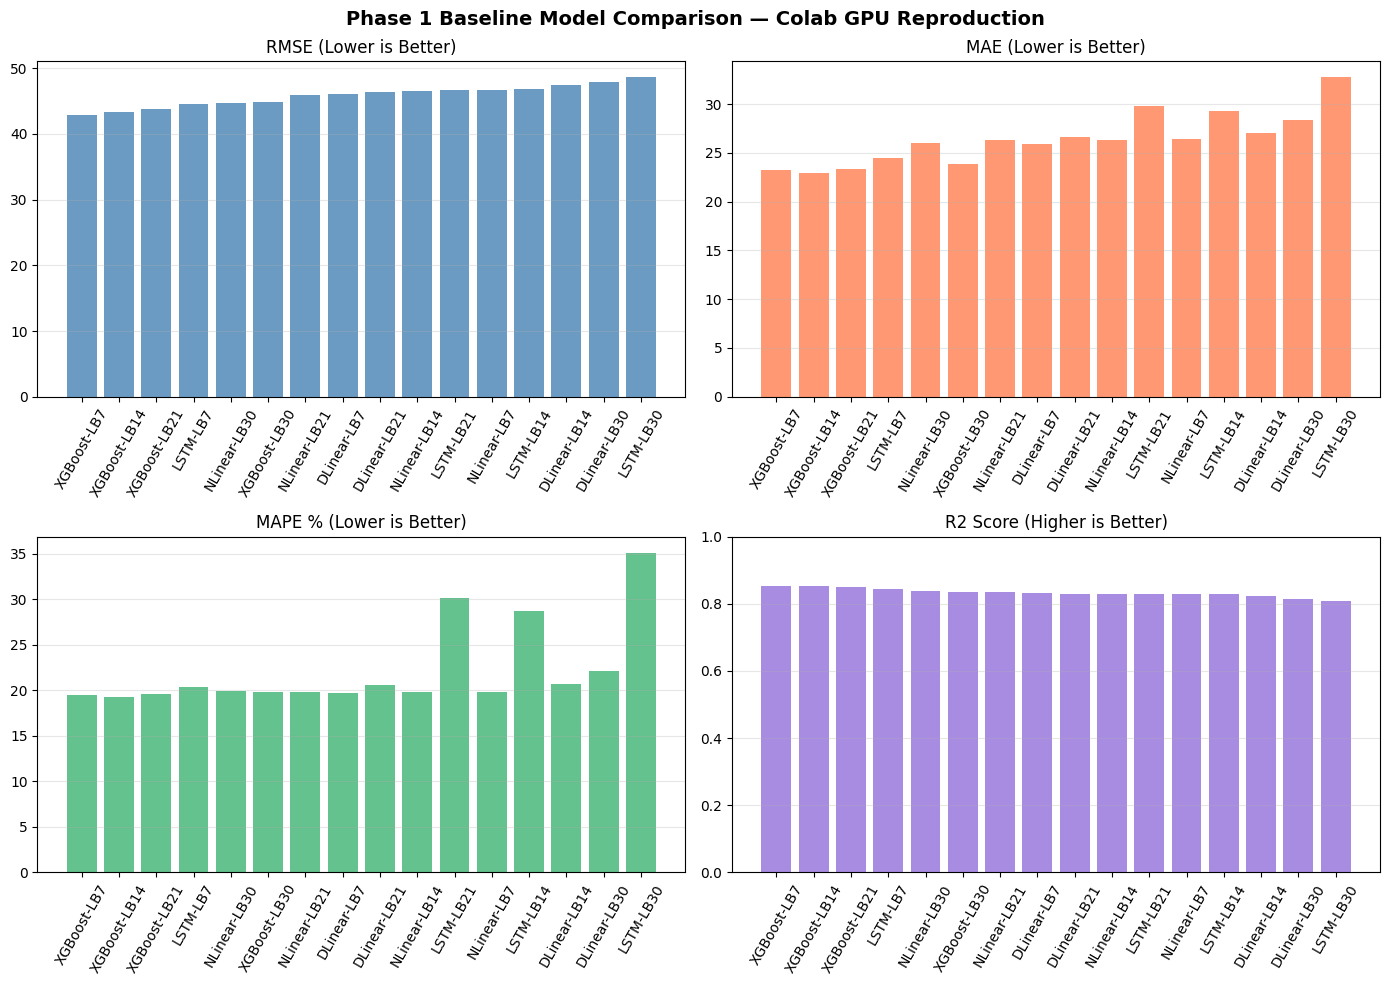

In [20]:
# Bar chart comparison (mirrors run_comparison.py's 4-panel figure)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Phase 1 Baseline Model Comparison — Colab GPU Reproduction", fontsize=14, fontweight="bold")

labels = results_df["label"].tolist()

axes[0, 0].bar(labels, results_df["RMSE"], color="steelblue", alpha=0.8)
axes[0, 0].set_title("RMSE (Lower is Better)")
axes[0, 0].tick_params(axis="x", rotation=60)
axes[0, 0].grid(axis="y", alpha=0.3)

axes[0, 1].bar(labels, results_df["MAE"], color="coral", alpha=0.8)
axes[0, 1].set_title("MAE (Lower is Better)")
axes[0, 1].tick_params(axis="x", rotation=60)
axes[0, 1].grid(axis="y", alpha=0.3)

axes[1, 0].bar(labels, results_df["MAPE"], color="mediumseagreen", alpha=0.8)
axes[1, 0].set_title("MAPE % (Lower is Better)")
axes[1, 0].tick_params(axis="x", rotation=60)
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].bar(labels, results_df["R2"], color="mediumpurple", alpha=0.8)
axes[1, 1].set_title("R2 Score (Higher is Better)")
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis="x", rotation=60)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


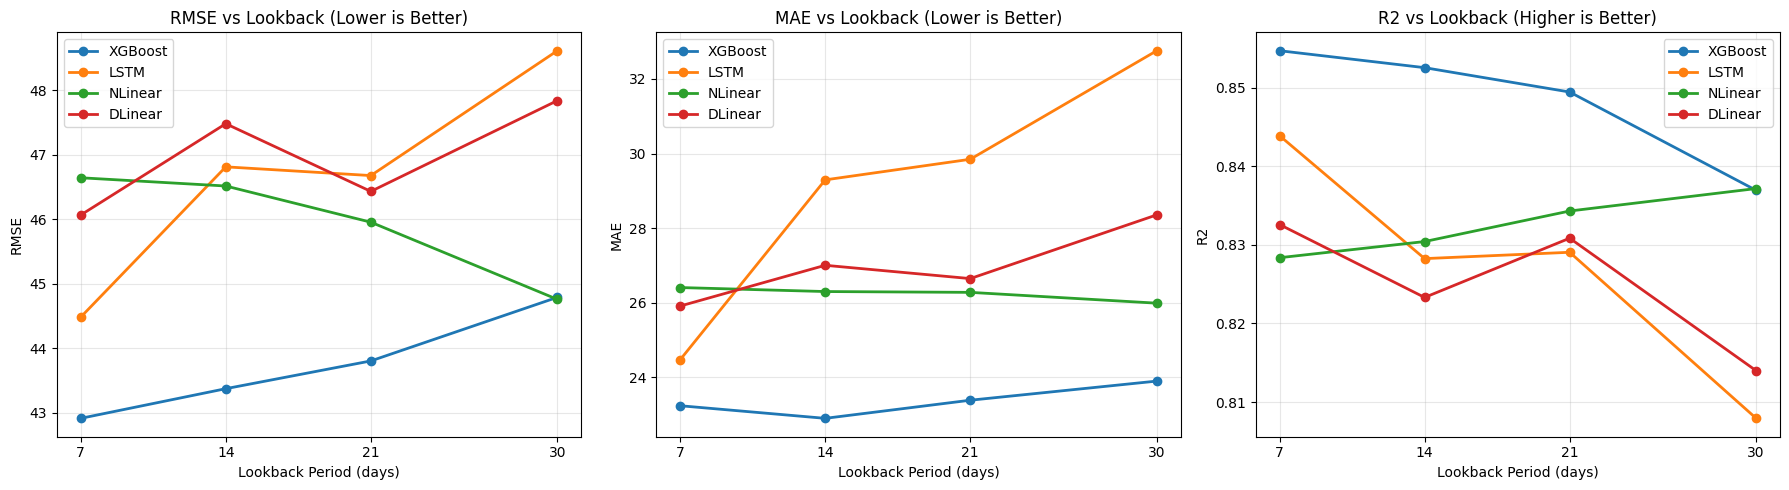

In [21]:
# Line plots: metric vs. lookback period, one line per model (mirrors compare_lookback_comprehensive.py)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_present = results_df["model"].unique().tolist()

for metric, ax, better in [("RMSE", axes[0], "Lower"), ("MAE", axes[1], "Lower"), ("R2", axes[2], "Higher")]:
    for m in models_present:
        sub = results_df[results_df["model"] == m].sort_values("lookback")
        ax.plot(sub["lookback"], sub[metric], marker="o", label=m, linewidth=2)
    ax.set_xlabel("Lookback Period (days)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Lookback ({better} is Better)")
    ax.set_xticks(LOOKBACK_PERIODS)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
# Optional: save results for download / later reuse
results_df.to_csv("phase1_colab_comparison_metrics.csv", index=False)
with open("phase1_colab_comparison_summary.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)
print("Saved: phase1_colab_comparison_metrics.csv, phase1_colab_comparison_summary.json")


Saved: phase1_colab_comparison_metrics.csv, phase1_colab_comparison_summary.json
